In [1]:
# Execute this first 
#
#  * trigger notebook styling
#  * check if notebook had been modified since its distribution
# 
# Note: executing any cells before this modifies the notebook.
# 
%run src/init_notebooks.py
hide_toggle()
#check_notebook()

In [2]:
import nglview as ng
import pandas as pd
import mdtraj as md
import numpy as np

In [3]:
# Go To Methane directory and use 94K
%cd ~/gromacs/build/Titan/Melamine
!ls

/home/dragns/gromacs/build/Titan/Melamine
 2205105.cif	  md.edr	       npt1.cpt   nvt.tpr
 ASEmelamine.py   md.gro	       npt1.edr   nvt.trr
 box.gro	  md.log	       npt1.gro   nvt.xtc
 CIFmelamine.py   mdout.mdp	       npt1.log   potential.xvg
 density1.xvg	  md.tpr	       npt1.mdp   pressure.xvg
 em.edr		  md.trr	       npt1.tpr   production.mdp
 em.gro		  md.xtc	       npt1.trr   ps2cm.py
 em.log		  melamine4.gro        npt1.xtc   Setup1
 em.mdp		  melamine7.gro        nvt.cpt	  SetupDOS
 em.tpr		  melamine_box.gro     nvt.edr	  temperature.xvg
 em.trr		  MelamineCrystal.py   nvt.gro	 '#temperature.xvg.1#'
 Ice_bonds.py	  melamine.gro	       nvt.log	  UNK_C2C3B8.gro
 md.cpt		  melamine.top	       nvt.mdp	  UNK_C2C3B8.itp


In [5]:
# Load and view the .pdb or .gro file with the following lines
view = ng.show_structure_file("melamine.gro")
view

NGLWidget()

In [6]:
# Create larger box to grow simulation
!gmx editconf -f melamine.gro -o box.gro -box 2.45 2.45 2.45 -noc

# Add the Melamine Molecules to the larger box
!gmx insert-molecules -f box.gro -ci melamine.gro -nmol 108 -box 2.45 2.45 2.45 -o melamine_box.gro -seed 12345 -try 10000

               :-) GROMACS - gmx editconf, 2024.3-conda_forge (-:

Executable:   /home/dragns/miniconda3/envs/md-intro-tutorial/bin.SSE2/gmx
Data prefix:  /home/dragns/miniconda3/envs/md-intro-tutorial
Working dir:  /home/dragns/gromacs/build/Titan/Melamine
Command line:
  gmx editconf -f melamine.gro -o box.gro -box 2.45 2.45 2.45 -noc

Note that major changes are planned in future for editconf, to improve usability and utility.
Read 15 atoms
Volume: 1 nm^3, corresponds to roughly 400 electrons
No velocities found
new box vectors :  2.450  2.450  2.450 (nm)
new box angles  :  90.00  90.00  90.00 (degrees)
new box volume  :  14.71               (nm^3)

GROMACS reminds you: "FORTRAN. Input: reason, output: pleasure" (ORDA, FORTRAN board game)

           :-) GROMACS - gmx insert-molecules, 2024.3-conda_forge (-:

Executable:   /home/dragns/miniconda3/envs/md-intro-tutorial/bin.SSE2/gmx
Data prefix:  /home/dragns/miniconda3/envs/md-intro-tutorial
Working dir:  /home/dragns/gromacs/build/

In [7]:
# View the system
view = ng.show_structure_file("melamine_box.gro")
view.clear_representations()
view.add_ball_and_stick()
view.camera = 'orthographic'
view.center()
view

NGLWidget()

In [8]:
#Energy Minimization
!gmx grompp -f em.mdp -c melamine_box.gro -p melamine.top -o em.tpr
!gmx mdrun -deffnm em -ntmpi 1 -ntomp 1

                :-) GROMACS - gmx grompp, 2024.3-conda_forge (-:

Executable:   /home/dragns/miniconda3/envs/md-intro-tutorial/bin.SSE2/gmx
Data prefix:  /home/dragns/miniconda3/envs/md-intro-tutorial
Working dir:  /home/dragns/gromacs/build/Titan/Melamine
Command line:
  gmx grompp -f em.mdp -c melamine_box.gro -p melamine.top -o em.tpr

Ignoring obsolete mdp entry 'ns_type'

NOTE 1 [file em.mdp]:
  With Verlet lists the optimal nstlist is >= 10, with GPUs >= 20. Note
  that with the Verlet scheme, nstlist has no effect on the accuracy of
  your simulation.

Setting the LD random seed to 1034813311

Generated 120 of the 120 non-bonded parameter combinations
Generating 1-4 interactions: fudge = 0.5

Generated 120 of the 120 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'MEL'
Analysing residue names:
There are:   106      Other residues
Analysing residues not classified as Protein/DNA/RNA/Water and splitting into groups...
Number of degrees of freedom in T-Coup

                :-) GROMACS - gmx energy, 2024.3-conda_forge (-:

Executable:   /home/dragns/miniconda3/envs/md-intro-tutorial/bin.SSE2/gmx
Data prefix:  /home/dragns/miniconda3/envs/md-intro-tutorial
Working dir:  /home/dragns/gromacs/build/Titan/Melamine
Command line:
  gmx energy -f em.edr -o potential.xvg -xvg none

Opened em.edr as single precision energy file

Select the terms you want from the following list by
selecting either (part of) the name or the number or a combination.
End your selection with an empty line or a zero.
-------------------------------------------------------------------
  1  Bond             2  Angle            3  Ryckaert-Bell.   4  Per.-Imp.-Dih.
  5  LJ-14            6  Coulomb-14       7  LJ-(SR)          8  Disper.-corr. 
  9  Coulomb-(SR)    10  Coul.-recip.    11  Potential       12  Pres.-DC      
 13  Pressure        14  Vir-XX          15  Vir-XY          16  Vir-XZ        
 17  Vir-YX          18  Vir-YY          19  Vir-YZ          20  Vir-ZX  

<Axes: xlabel='step'>

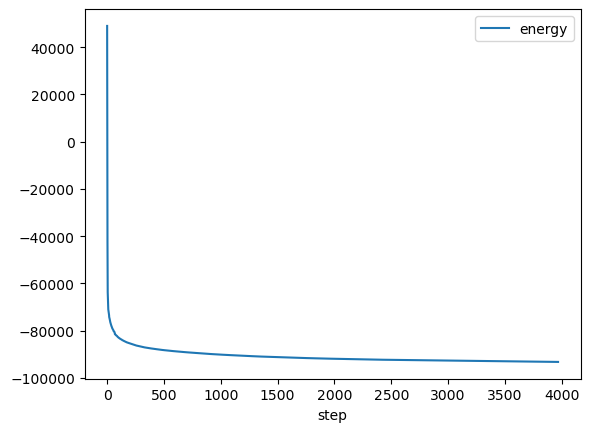

In [9]:
#Analyze results of EM
!printf "Potential\n0\n" | gmx energy -f em.edr -o potential.xvg -xvg none
# Print graph
df = pd.read_csv('potential.xvg', sep='\\s+', header=None, names=['step','energy'])
df.plot('step')

In [10]:
# Temperature EQ T= 300 K
!gmx grompp -f nvt.mdp -c em.gro -r em.gro -p melamine.top -o nvt.tpr 
!gmx mdrun -ntmpi 1 -ntomp 6 -v -deffnm nvt

                :-) GROMACS - gmx grompp, 2024.3-conda_forge (-:

Executable:   /home/dragns/miniconda3/envs/md-intro-tutorial/bin.SSE2/gmx
Data prefix:  /home/dragns/miniconda3/envs/md-intro-tutorial
Working dir:  /home/dragns/gromacs/build/Titan/Melamine
Command line:
  gmx grompp -f nvt.mdp -c em.gro -r em.gro -p melamine.top -o nvt.tpr

Ignoring obsolete mdp entry 'ns_type'
Setting the LD random seed to 2006973435

Generated 120 of the 120 non-bonded parameter combinations
Generating 1-4 interactions: fudge = 0.5

Generated 120 of the 120 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'MEL'

Setting gen_seed to -536873026

Velocities were taken from a Maxwell distribution at 300 K
Analysing residue names:
There are:   106      Other residues
Analysing residues not classified as Protein/DNA/RNA/Water and splitting into groups...
Number of degrees of freedom in T-Coupling group System is 4767.00

The largest distance between excluded atoms is 0.354 nm between

                :-) GROMACS - gmx energy, 2024.3-conda_forge (-:

Executable:   /home/dragns/miniconda3/envs/md-intro-tutorial/bin.SSE2/gmx
Data prefix:  /home/dragns/miniconda3/envs/md-intro-tutorial
Working dir:  /home/dragns/gromacs/build/Titan/Melamine
Command line:
  gmx energy -f nvt.edr -o temperature.xvg -xvg none -b 20

Opened nvt.edr as single precision energy file

Select the terms you want from the following list by
selecting either (part of) the name or the number or a combination.
End your selection with an empty line or a zero.
-------------------------------------------------------------------
  1  Bond             2  Angle            3  Ryckaert-Bell.   4  Per.-Imp.-Dih.
  5  LJ-14            6  Coulomb-14       7  LJ-(SR)          8  Coulomb-(SR)  
  9  Coul.-recip.    10  Potential       11  Kinetic-En.     12  Total-Energy  
 13  Conserved-En.   14  Temperature     15  Pressure        16  Vir-XX        
 17  Vir-XY          18  Vir-XZ          19  Vir-YX          20

<Axes: xlabel='time'>

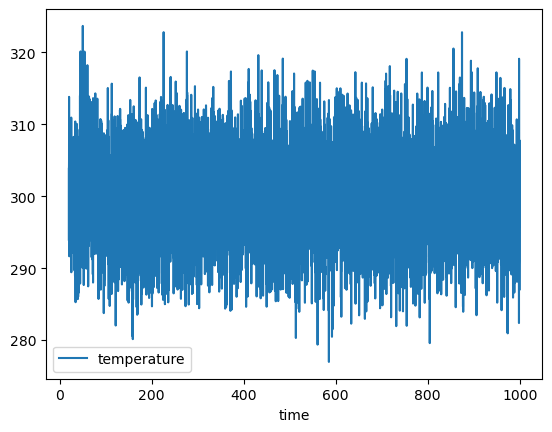

In [11]:
# Analyze Temp run
!echo "Temperature" | gmx energy -f nvt.edr -o temperature.xvg -xvg none -b 20
# Plot Temp data
df = pd.read_csv('temperature.xvg', sep='\\s+', header=None, names=['time','temperature'])
df.plot('time')

In [12]:
# Pressure EQ P = 1.0 bars
!gmx grompp -f npt1.mdp -c nvt.gro -r nvt.gro -t nvt.cpt -p melamine.top -o npt1.tpr -maxwarn 1
!gmx mdrun -ntmpi 1 -ntomp 6 -v -deffnm npt1

                :-) GROMACS - gmx grompp, 2024.3-conda_forge (-:

Executable:   /home/dragns/miniconda3/envs/md-intro-tutorial/bin.SSE2/gmx
Data prefix:  /home/dragns/miniconda3/envs/md-intro-tutorial
Working dir:  /home/dragns/gromacs/build/Titan/Melamine
Command line:
  gmx grompp -f npt1.mdp -c nvt.gro -r nvt.gro -t nvt.cpt -p melamine.top -o npt1.tpr -maxwarn 1

Ignoring obsolete mdp entry 'ns_type'
Setting the LD random seed to -188749825

Generated 120 of the 120 non-bonded parameter combinations
Generating 1-4 interactions: fudge = 0.5

Generated 120 of the 120 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'MEL'
Analysing residue names:
There are:   106      Other residues
Analysing residues not classified as Protein/DNA/RNA/Water and splitting into groups...
Number of degrees of freedom in T-Coupling group System is 4767.00

The largest distance between excluded atoms is 0.368 nm between atom 796 and 802

Determining Verlet buffer for a tolerance of 0.

                :-) GROMACS - gmx energy, 2024.3-conda_forge (-:

Executable:   /home/dragns/miniconda3/envs/md-intro-tutorial/bin.SSE2/gmx
Data prefix:  /home/dragns/miniconda3/envs/md-intro-tutorial
Working dir:  /home/dragns/gromacs/build/Titan/Melamine
Command line:
  gmx energy -f npt1.edr -o pressure.xvg -xvg none

Opened npt1.edr as single precision energy file

Select the terms you want from the following list by
selecting either (part of) the name or the number or a combination.
End your selection with an empty line or a zero.
-------------------------------------------------------------------
  1  Bond             2  Angle            3  Ryckaert-Bell.   4  Per.-Imp.-Dih.
  5  LJ-14            6  Coulomb-14       7  LJ-(SR)          8  Disper.-corr. 
  9  Coulomb-(SR)    10  Coul.-recip.    11  Potential       12  Kinetic-En.   
 13  Total-Energy    14  Conserved-En.   15  Temperature     16  Pres.-DC      
 17  Pressure        18  Box-X           19  Box-Y           20  Box-Z

<Axes: xlabel='time'>

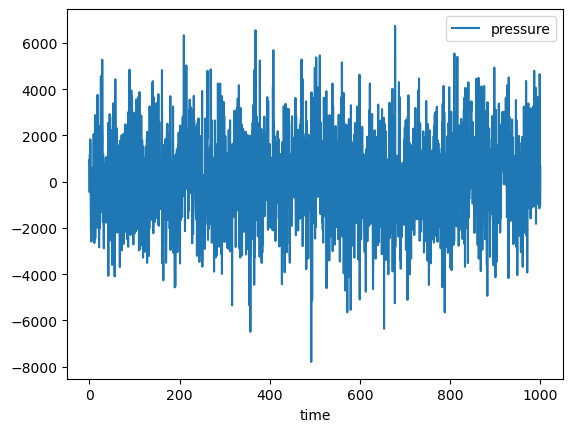

In [13]:
# Analyze Pressure Data
!echo "Pressure" | gmx energy -f npt1.edr -o pressure.xvg -xvg none
df = pd.read_csv('pressure.xvg', sep='\\s+', header=None, names=['time','pressure'])
df.plot('time')

In [ ]:
#!echo "Pressure" | gmx energy -f npt.edr -o pressure.xvg
#!xmgrace pressure.xvg

In [14]:
# Look at density of system
!echo "Density" | gmx energy -f npt1.edr -o density1.xvg -xvg none

                :-) GROMACS - gmx energy, 2024.3-conda_forge (-:

Executable:   /home/dragns/miniconda3/envs/md-intro-tutorial/bin.SSE2/gmx
Data prefix:  /home/dragns/miniconda3/envs/md-intro-tutorial
Working dir:  /home/dragns/gromacs/build/Titan/Melamine
Command line:
  gmx energy -f npt1.edr -o density1.xvg -xvg none

Opened npt1.edr as single precision energy file

Select the terms you want from the following list by
selecting either (part of) the name or the number or a combination.
End your selection with an empty line or a zero.
-------------------------------------------------------------------
  1  Bond             2  Angle            3  Ryckaert-Bell.   4  Per.-Imp.-Dih.
  5  LJ-14            6  Coulomb-14       7  LJ-(SR)          8  Disper.-corr. 
  9  Coulomb-(SR)    10  Coul.-recip.    11  Potential       12  Kinetic-En.   
 13  Total-Energy    14  Conserved-En.   15  Temperature     16  Pres.-DC      
 17  Pressure        18  Box-X           19  Box-Y           20  Box-Z

<Axes: xlabel='time'>

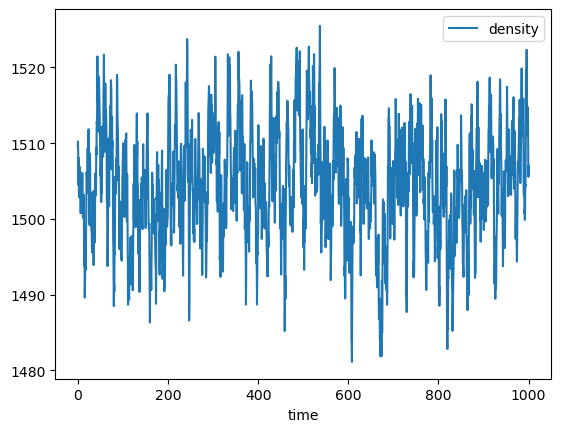

In [26]:
#Plot density
df = pd.read_csv('density1.xvg', sep='\\s+', header=None, names=['time','density'])
df.plot('time')

In [19]:
!tail -1 npt1.gro

   2.46279   2.45621   2.42795


In [15]:
# View the system
view = ng.show_structure_file("npt1.gro")
view.clear_representations()
view.add_ball_and_stick()
view.camera = 'orthographic'
view.center()
view

NGLWidget()

In [ ]:
# Pressure EQ Stage 2
!gmx grompp -f npt2.mdp -c npt1.gro -p topol.top -o npt2.tpr -maxwarn 1
!gmx mdrun -ntmpi 1 -ntomp 6 -v -deffnm npt2

In [ ]:
# Analyze Pressure Data
!echo "Pressure" | gmx energy -f npt2.edr -o pressure2.xvg -xvg none

df = pd.read_csv('pressure2.xvg', sep='\\s+', header=None, names=['time','pressure'])
df.plot('time')

In [ ]:
# Look at density of system
!echo "Density" | gmx energy -f npt2.edr -o density2.xvg -xvg none

#Plot density
df = pd.read_csv('density2.xvg', sep='\\s+', header=None, names=['time','density'])
df.plot('time')

In [16]:
#Production Run
!gmx grompp -f production.mdp -c npt1.gro -t npt1.cpt -p melamine.top -o md.tpr -maxwarn 1
!gmx mdrun -ntmpi 1 -ntomp 8 -pin on -v -deffnm md

                :-) GROMACS - gmx grompp, 2024.3-conda_forge (-:

Executable:   /home/dragns/miniconda3/envs/md-intro-tutorial/bin.SSE2/gmx
Data prefix:  /home/dragns/miniconda3/envs/md-intro-tutorial
Working dir:  /home/dragns/gromacs/build/Titan/Melamine
Command line:
  gmx grompp -f production.mdp -c npt1.gro -t npt1.cpt -p melamine.top -o md.tpr -maxwarn 1

Ignoring obsolete mdp entry 'ns_type'
Setting the LD random seed to -135431763

Generated 120 of the 120 non-bonded parameter combinations
Generating 1-4 interactions: fudge = 0.5

Generated 120 of the 120 1-4 parameter combinations

Excluding 3 bonded neighbours molecule type 'MEL'
Analysing residue names:
There are:   106      Other residues
Analysing residues not classified as Protein/DNA/RNA/Water and splitting into groups...
Number of degrees of freedom in T-Coupling group System is 4767.00

The largest distance between excluded atoms is 0.364 nm between atom 992 and 995

Determining Verlet buffer for a tolerance of 0.005 k

In [20]:
import os
print("md.trr exists:", os.path.exists("md.trr"))
print("melamine_box.gro exists:", os.path.exists("melamine_box.gro"))

md.trr exists: True
melamine_box.gro exists: True


In [ ]:
import mdtraj as md
import os

# Check files exist
print("md.trr exists:", os.path.exists("md.trr"))
print("melamine_box.gro exists:", os.path.exists("melamine_box.gro"))

# Load and check trajectory
try:
    traj = md.load_trr("md.trr", top="melamine_box.gro", stride=10)
    print(f"Loaded trajectory: {traj.n_frames} frames, {traj.n_atoms} atoms")
    print(f"Time range: {traj.time[0]:.1f} to {traj.time[-1]:.1f} ps")
    
    # Try creating view
    view = ng.show_mdtraj(traj)
    print(f"View created: {type(view)}")
    
    # Display
    view
except Exception as e:
    print(f"Error: {e}")

In [ ]:
import nglview as ng
import mdtraj as md

# Enable widget rendering
ng.default_view_backend = 'notebook'  # or 'ipywidgets'
# Load trajectory
traj = md.load_trr("md.trr", top="md.gro")
view = ng.show_mdtraj(traj)
# Display
view

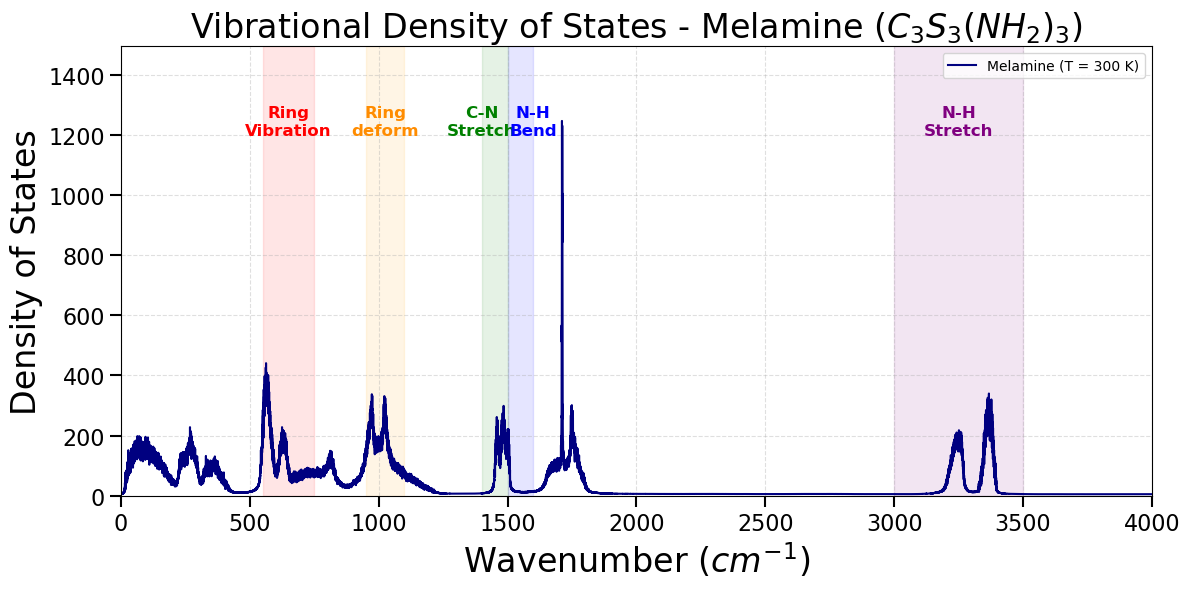

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Load the data 
# Added '#' to comment handling as GROMACS files use both @ and #
df_dos = pd.read_csv(
    'dos.xvg', 
    sep=r'\s+', 
    comment='@', 
    header=None,
    on_bad_lines='skip',
    engine='python'
)

# 2. Convert everything to numeric
df_dos = df_dos.apply(pd.to_numeric, errors='coerce')

# 3. Drop rows that are completely NaN and filter out '#' comment lines
df_dos = df_dos.dropna(how='all').reset_index(drop=True)

# 4. Use first two columns: Frequency and DOS
df_dos = df_dos.iloc[:, :2] 
df_dos.columns = ['freq', 'dos']

# 5. Convert Frequency (ps^-1) to Wavenumber (cm^-1)
# 1 ps^-1 = 33.35641 cm^-1
df_dos['freq_cm'] = df_dos['freq'] * 33.35641

# 6. Create the plot
plt.figure(figsize=(12, 6))

if not df_dos.empty:
    plt.plot(df_dos['freq_cm'], df_dos['dos'], color='navy', linewidth=1.5, label='Melamine (T = 300 K)')
    # --- Highlight Physics Regions for Methane ---
    
    # 1. Define the vertical anchor for labels
    max_dos = df_dos['dos'].max()
    label_y = max_dos * 1.05  # Position labels 5% above the highest peak

    # 2. Ring Breathing
    plt.axvspan(550, 750, color='red', alpha=0.1)
    plt.text(650, 1200, "Ring\nVibration", color='red', ha='center', weight='bold',fontsize=12)

    # 3. Ring deformation
    plt.axvspan(950, 1100, color='orange', alpha=0.1)
    plt.text(1025, 1200, "Ring\ndeform", color='darkorange', ha='center', weight='bold',fontsize=12)

    # 4. C-N Stretch
    plt.axvspan(1400, 1500, color='green', alpha=0.1)
    plt.text(1400, 1200, "C-N\nStretch", color='green', ha='center', weight='bold',fontsize=12)

    # 5. N-H Bend
    plt.axvspan(1500, 1600, color='blue', alpha=0.1)
    plt.text(1600, 1200, "N-H\nBend", color='blue', ha='center', weight='bold',fontsize=12)

    # 6. N-H Stretch
    plt.axvspan(3000, 3500, color='purple', alpha=0.1)
    plt.text(3250, 1200, "N-H\nStretch", color='purple', ha='center', weight='bold',fontsize=12)
    
    # Styling
    plt.title('Vibrational Density of States - Melamine ($C_{3}S_{3}(NH_{2})_{3}$)', fontsize=24)
    plt.xlabel('Wavenumber ($cm^{-1}$)', fontsize=24)
    plt.ylabel('Density of States', fontsize=24)
    plt.grid(True, linestyle='--', alpha=0.4)
    
    plt.xlim(0, 4000) 
    plt.ylim(0, max_dos * 1.2)

    plt.tick_params(
    axis='both',        # 'x', 'y', or 'both'
    which='major',      # major ticks
    labelsize=16,       # font size of tick labels
    length=8,           # tick mark length
    width=1.5           # tick mark width
    )
    
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()
else:
    print("The dataframe is empty. Check your .xvg file path and format.")